In [6]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import Adam

def set_global_seed(seed_value=42):
    # 1. Thiết lập seed cho môi trường Python (Environment Variable)
    os.environ['PYTHONHASHSEED'] = str(seed_value)
    
    # 2. Thiết lập seed cho các hàm random cơ bản của Python
    random.seed(seed_value)
    
    # 3. Thiết lập seed cho NumPy (ảnh hưởng đến việc xáo trộn/chia dữ liệu)
    np.random.seed(seed_value)
    
    # 4. Thiết lập seed cho TensorFlow (ảnh hưởng đến khởi tạo trọng số, Dropout)
    tf.random.set_seed(seed_value)
    
    # (Tùy chọn cho GPU) Ép TensorFlow chạy các thuật toán có tính tất định
    tf.config.experimental.enable_op_determinism()

# Gọi hàm ngay trước khi tải dữ liệu hoặc định nghĩa mô hình
set_global_seed(42)

In [7]:

# MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

# Chuẩn hóa dữ liệu (đưa về khoảng 0-1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# Thêm chiều kênh (vì ảnh đen trắng)
x_train = x_train[..., None]
x_test = x_test[..., None]

In [8]:


# Tạo mô hình
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(10, activation='softmax')
])





In [9]:
#tham số cần tham khảo và kiểm tra
my_learning_rate = 0.001
my_epochs = 10
my_batch_size = 32
# Cấu hình cách học
optimizer = Adam(learning_rate=my_learning_rate)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    x_train, y_train, 
    epochs=my_epochs, 
    batch_size=my_batch_size, 
    validation_data=(x_test, y_test) 
)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 17s 8ms/step - accuracy: 0.8486 - loss: 0.4357 - val_accuracy: 0.8788 - val_loss: 0.3473
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8925 - loss: 0.3082 - val_accuracy: 0.8890 - val_loss: 0.3159
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 21s 7ms/step - accuracy: 0.9036 - loss: 0.2751 - val_accuracy: 0.8944 - val_loss: 0.3009
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 9ms/step - accuracy: 0.9103 - loss: 0.2527 - val_accuracy: 0.8982 - val_loss: 0.2907
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9165 - loss: 0.2339 - val_accuracy: 0.8989 - val_loss: 0.2836
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.9219 - loss: 0.2173 - val_accuracy: 0.9027 - val_loss: 0.2791
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.9281 - loss: 0.2028 - val_accuracy: 0.9042 - val_loss: 0.2768
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 24s 13ms/step - accuracy: 0.9326 - loss:

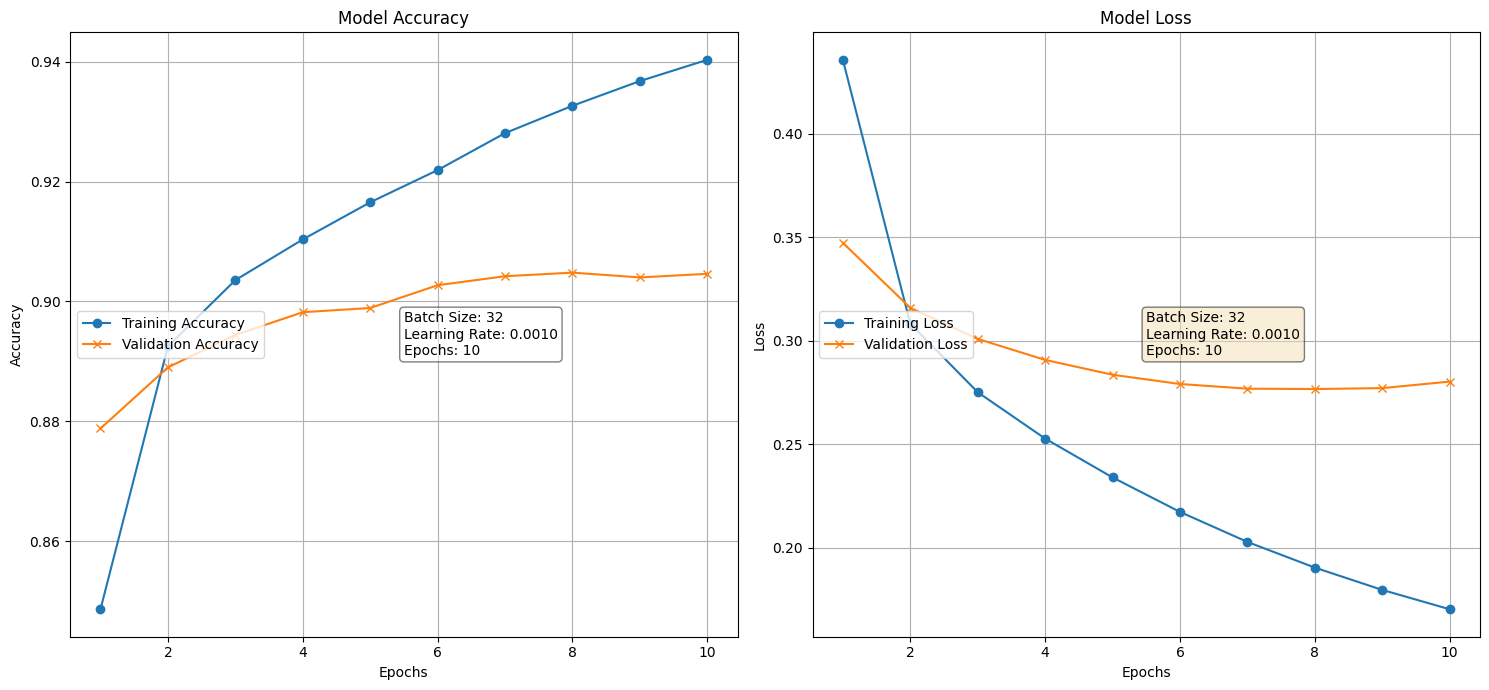

In [10]:
import matplotlib.pyplot as plt

# 1. Trích xuất dữ liệu từ history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(1, len(acc) + 1)

# 2. Chuẩn bị nội dung chú thích (Annotation)
# Lấy giá trị learning rate từ optimizer để đảm bảo chính xác
current_lr = model.optimizer.learning_rate.numpy() 
info_text = f'Batch Size: {my_batch_size}\nLearning Rate: {current_lr:.4f}\nEpochs: {my_epochs}'

plt.figure(figsize=(15, 7))

# --- Biểu đồ Accuracy ---
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='center left')
plt.grid(True)

# Chèn chú thích thông số vào góc biểu đồ
plt.text(0.5, 0.5, info_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='center', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

# --- Biểu đồ Loss ---
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='center left')
plt.grid(True)

# Chèn chú thích thông số tương tự
plt.text(0.5, 0.5, info_text, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='center', horizontalalignment='left',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()